# Load a saved HBR model and check convergence

First download the model from [SURFDrive](https://surfdrive.surf.nl/s/Mb6mZyFmJeCaPcZ?dir=/zip), and make sure to unzip it as `HBR_Sb_sa_DES_lifespan_37K_66sites/model/...` (the `model/` folder has to be there)

In [21]:
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt

from pcntoolkit.normative_model import NormativeModel


MODEL_DIR = "HBR_Sb_ct_DK_lifespan_79K_100sites"
RESPONSE_VAR = "L_caudalanteriorcingulate"

print(os.getcwd())

c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local


# Load a saved HBR model
## 1. Load

Point `load` at the folder *containing* `model/`, not at the response-var folder.
It reads `model/normative_model.json`, then walks every response-var subdirectory
and pulls in each `idata.nc`.

In [22]:
with warnings.catch_warnings():
    model = NormativeModel.load(MODEL_DIR)

print(f"response vars : {len(model.response_vars)}")
print(f"covariates    : {model.covariates}")
print(f"batch effects : {model.batch_effect_dims}")
print(f"first few     : {model.response_vars[:5]}")

c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:05 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:05 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:05 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:05 - This model was saved with PCNtoolkit v1.1.1, but

response vars : 70
covariates    : ['age']
batch effects : ['sex', 'site_id2']
first few     : ['L_bankssts', 'L_caudalanteriorcingulate', 'L_caudalmiddlefrontal', 'L_cuneus', 'L_entorhinal']


c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:08 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:08 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:08 - This model was saved with PCNtoolkit v1.1.1, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
c:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 17280 - 2026-08-05 14:29:08 - This model was saved with PCNtoolkit v1.1.1, but

## 2. One regression model

`model[response_var]` gives the `HBR` estimator for that region. `is_fitted=True`
means its posterior was read off disk.

In [23]:
rm = model[RESPONSE_VAR]

print(f"type       : {type(rm).__name__}")
print(f"is_fitted  : {rm.is_fitted}")
print(f"likelihood : {rm.likelihood.name}")
print(f"sampler    : {rm.nuts_sampler}, {rm.chains} chains x {rm.draws} draws (tune {rm.tune})")

# Batch-effect maps: how the original label values map to model indices.
for be_dim, be_map in rm.be_maps.items():
    print(f"{be_dim:10s}: {len(be_map)} levels")

type       : HBR
is_fitted  : True
likelihood : SHASHb
sampler    : nutpie, 4 chains x 1500 draws (tune 500)
sex       : 2 levels
site_id2  : 83 levels


# Check convergence
## 3. The idata

In [24]:
print(rm.idata)
print()
print("dims           :", dict(rm.idata.posterior.sizes))

Inference data with groups:
	> posterior

dims           : {'chain': 4, 'draw': 1500, 'mu_covariates': 8, 'sex': 2, 'site_id2': 83, 'sigma_covariates': 8}


In [ ]:
for name, da in rm.idata.posterior.data_vars.items():
    extra = [d for d in da.dims if d not in ("chain", "draw")]
    print(f"{name:40s} {str(extra) if extra else '(scalar)'}")

slope_mu                                 ['mu_covariates']
mu_intercept_mu                          (scalar)
sex_sigma_intercept_mu                   (scalar)
normalized_sex_offset_intercept_mu       ['sex']
site_id2_sigma_intercept_mu              (scalar)
normalized_site_id2_offset_intercept_mu  ['site_id2']
slope_sigma                              ['sigma_covariates']
intercept_sigma                          (scalar)
epsilon                                  (scalar)
delta                                    (scalar)
sex_offset_intercept_mu                  ['sex']
site_id2_offset_intercept_mu             ['site_id2']


## 4. Posterior summary - see what did not converge based on `r_hat`

Watch the `r_hat` column — anything well above 1.01 means the chains did not mix
for that parameter.

Also the lower the `ESS` the worst. The usual rule is ESS > 100 per chain, so ≥ 400 for your 4 chains. 

*Theory:*

**r_hat** — did the 4 chains agree? Want < 1.01. Higher = they explored different places.

**ESS** — how many draws actually count. MCMC draws are correlated, so 6000 draws
are worth fewer independent ones. Want > 400 (100 per chain).

*Example:*

Here `slope_mu[mu_covariates_3]` has r_hat 1.35 and ESS_bulk 10: 6000 draws carrying as much information
as 10 independent samples — like asking 6000 people but it's actually 10 people repeating
themselves. Both are the same symptom: the chains didn't mix.

In [26]:
summary = az.summary(rm.idata)
print(f"parameters: {len(summary)}")
summary.sort_values("r_hat", ascending=False).head(20) # show only the 20 parameters with the highest R-hat values (worst convergence)

parameters: 192


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
slope_mu[mu_covariates_3],-0.757,2.217,-4.794,3.789,0.707,0.224,10.0,47.0,1.35
normalized_sex_offset_intercept_mu[1.0],-0.092,0.729,-1.450,1.197,0.231,0.065,10.0,41.0,1.32
normalized_sex_offset_intercept_mu[0.0],-0.025,0.728,-1.335,1.302,0.231,0.064,10.0,45.0,1.32
slope_mu[mu_covariates_2],0.141,3.206,-5.103,7.110,0.986,0.357,11.0,25.0,1.31
sex_offset_intercept_mu[1.0],-0.169,1.483,-2.886,2.439,0.466,0.147,10.0,44.0,1.31
sex_offset_intercept_mu[0.0],-0.044,1.483,-2.888,2.429,0.466,0.147,10.0,44.0,1.31
slope_mu[mu_covariates_1],0.872,3.784,-5.496,8.945,1.148,0.478,11.0,18.0,1.29
slope_mu[mu_covariates_4],-0.151,1.914,-3.940,3.398,0.568,0.264,12.0,34.0,1.28
slope_mu[mu_covariates_0],-0.326,1.987,-4.193,3.739,0.561,0.341,13.0,17.0,1.23
slope_mu[mu_covariates_5],-0.419,3.252,-6.102,6.256,0.871,0.373,14.0,34.0,1.23


In [27]:
# How bad is the mixing overall?
print(summary["r_hat"].describe())
print()
print(f"params with r_hat > 1.01 : {(summary['r_hat'] > 1.01).sum()} / {len(summary)}")
print(f"params with ess_bulk < 400: {(summary['ess_bulk'] < 400).sum()} / {len(summary)}")

count    192.000000
mean       1.022812
std        0.068403
min        1.000000
25%        1.000000
50%        1.010000
75%        1.010000
max        1.350000
Name: r_hat, dtype: float64

params with r_hat > 1.01 : 13 / 192
params with ess_bulk < 400: 13 / 192


## 5. Trace plots



Line style = chain (4), colour = coordinate within the variable.

The scalars are one colour in 4 styles (4 chains). `slope_mu` has 8 colours because it has,
8 (5 knots + 3 degrees) B-spline coefficients for `age`. This was also seen earlier where we printed:
slope_mu has the 'mu_covariates' dimensio and 'mu_covariates' has 8 dimensions


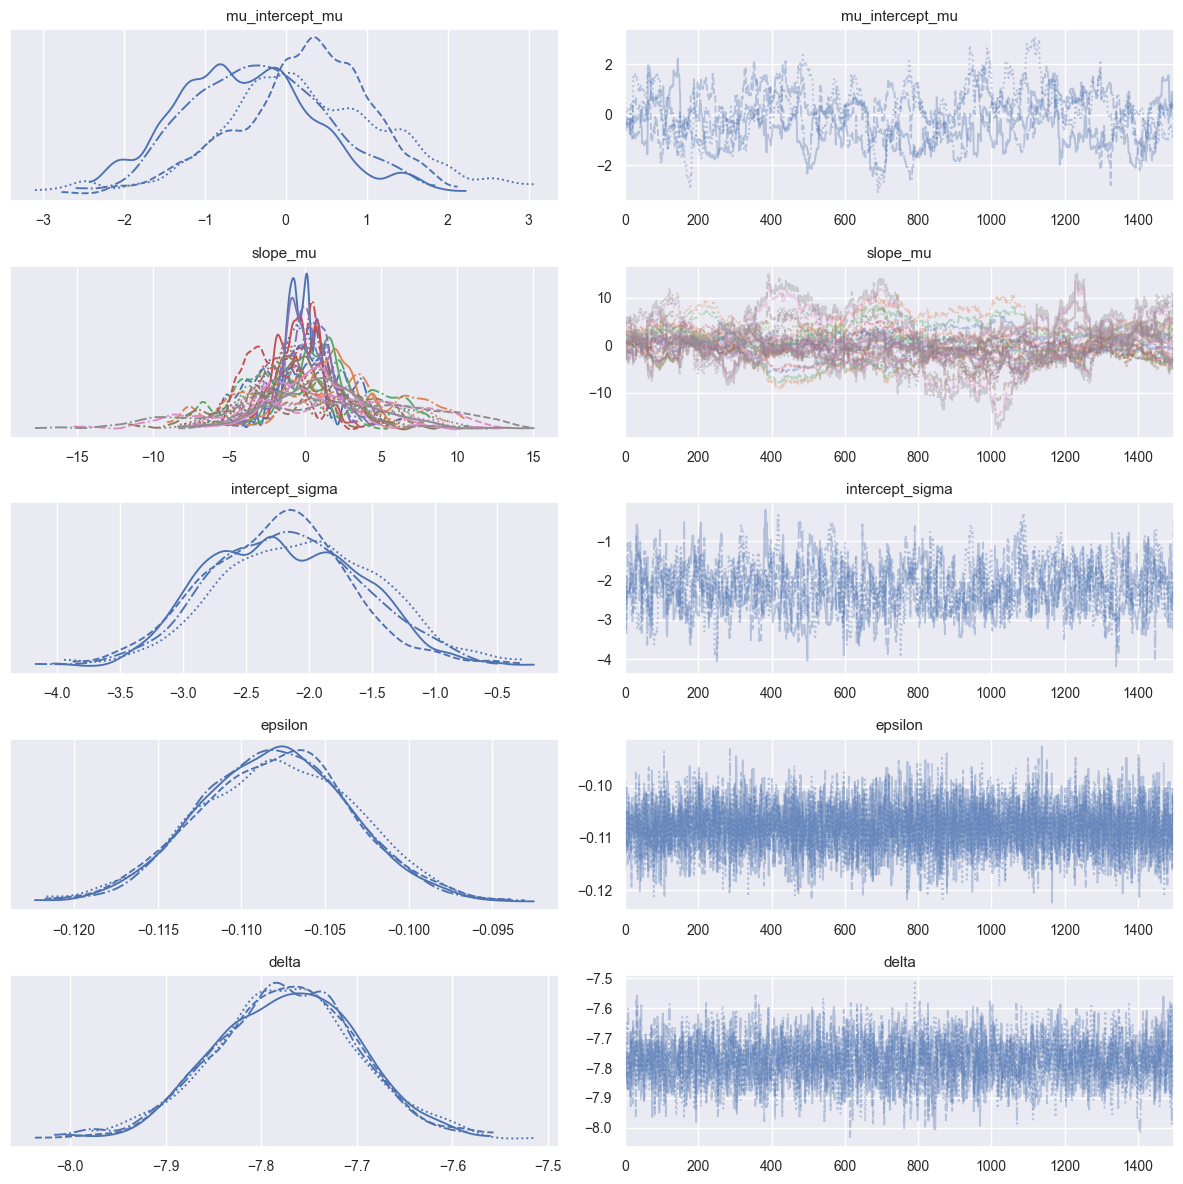

In [28]:
az.plot_trace(
    rm.idata,
    var_names=["mu_intercept_mu", "slope_mu", "intercept_sigma", "epsilon", "delta"],
    figsize=(12, 12),
)
plt.tight_layout()
plt.show()

## 6. Site effects

`site_id2_offset_intercept_mu` is the per-site shift in the mean - the thing
harmonization removes. 

Because there are a lot of sites we will not plot them in a traceplot as above but in a forest plot over 83 sites to show the spread.

*Explain the plot:*

dot = posterior mean, thin line = 94% HDI, thick line = 50% HDI.

HDI = Highest Density Interval. The Bayesian version of a confidence interval.

94% HDI means: given the data and the model, there's a 94% probability the parameter lies in that range.

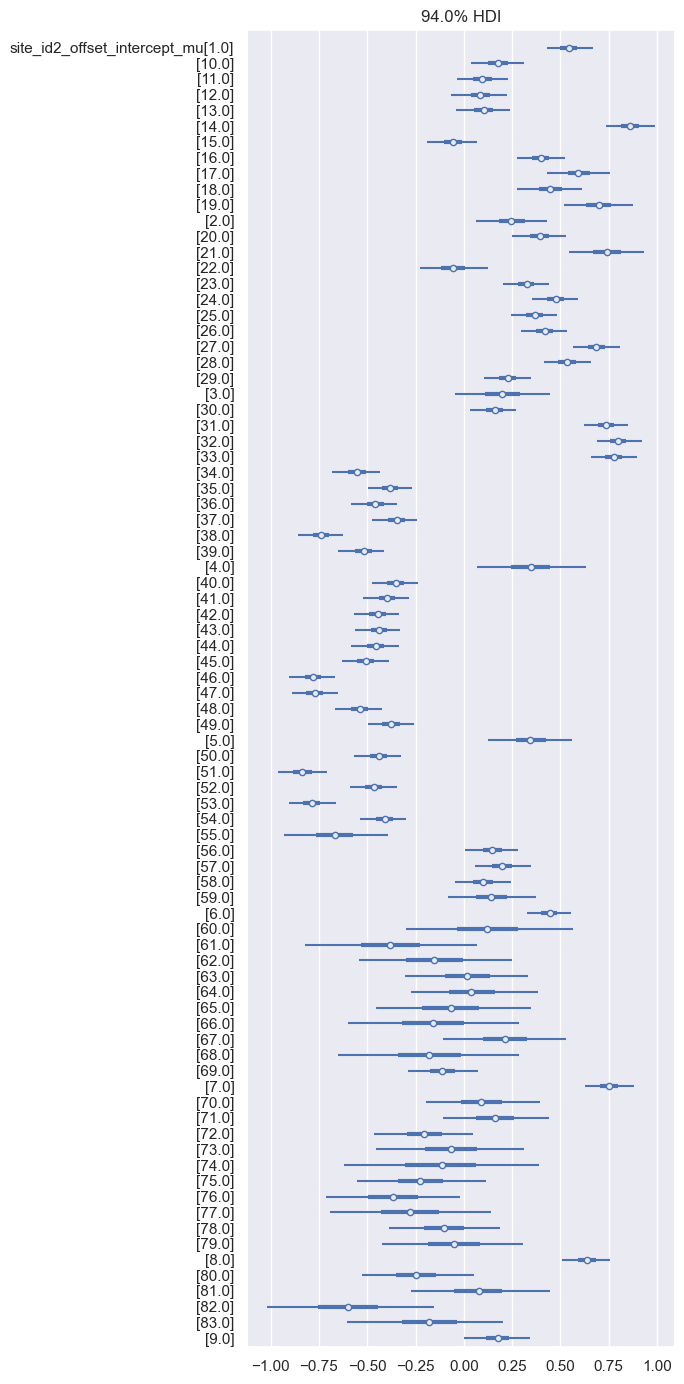

In [29]:
az.plot_forest(
    rm.idata,
    var_names=["site_id2_offset_intercept_mu"],
    combined=True,
    figsize=(7, 14),
)
plt.tight_layout()
plt.show()

## 7. Compare across regions

Every region is a separate `HBR` with its own posterior. Worst r_hat per region is
a quick way to spot which fits are untrustworthy.

Here we check all regions, but only get the worst fit over 3 parameters (mu_intercept_mu, epsilon, delta) -> that is different to what we did in an earlier cell where we checked one region (rm = RESPONSE_VAR only) but all parameters.

In [30]:
rows = []
for rv in model.response_vars:
    s = az.summary(model[rv].idata, var_names=["mu_intercept_mu", "epsilon", "delta"])
    rows.append((rv, s["r_hat"].max(), s["ess_bulk"].min()))

import pandas as pd

df = pd.DataFrame(rows, columns=["response_var", "max_r_hat", "min_ess_bulk"])
df.sort_values("max_r_hat", ascending=False).head(15)

,response_var,max_r_hat,min_ess_bulk
60,R_precentral,1.45,8.0
18,L_parsopercularis,1.28,12.0
66,R_superiortemporal,1.26,14.0
41,R_frontalpole,1.25,15.0
34,Mean_Thickness,1.24,15.0
25,L_precuneus,1.21,14.0
61,R_precuneus,1.18,18.0
63,R_rostralmiddlefrontal,1.17,18.0
0,L_bankssts,1.15,19.0
64,R_superiorfrontal,1.13,27.0
